## **Problem Statment**

Organizations often receive large volumes of documents that must be quickly interpreted to extract key information and produce actionable insights. Manually processing these documents is time-consuming, error-prone, and difficult to scale. 

There is a need for an automated pipeline that can reliably ingest documents, extract relevant content, and generate structured analysis reports while maintaining flexibility to call external tools during the extraction process. The solution should orchestrate multiple specialized agents, ensure seamless handoff between parsing and analysis stages, and efficiently manage execution flow within a scalable agent-based architecture.

### **Step 1: Init a AgentServiceFactory**

In [1]:
from azure.identity import DefaultAzureCredential
from langchain_azure_ai.agents import AgentServiceFactory
from langchain_azure_ai.utils.agents import pretty_print

AZURE_AI_PROJECT_ENDPOINT="https://resource-ms-foundary.services.ai.azure.com/api/projects/proj-ms-foundary"

factory = AgentServiceFactory(
	project_endpoint=AZURE_AI_PROJECT_ENDPOINT,
	credential=DefaultAzureCredential(),
)

### **Step 2: Create a Document Parser Agent**

The method `create_prompt_agent_node` returns a node instead of a compiled graph, which can be used later with other nodes.

In [2]:
DOC_INTELLIGENCE_ENDPOINT = "https://docintelligenceinstance321.cognitiveservices.azure.com/"

with open("keys/.azure_di_api_key.txt") as f:
    DOC_INTELLIGENCE_KEY = f.read()

In [3]:
from langchain_azure_ai.tools import AzureAIDocumentIntelligenceTool
from azure.core.credentials import AzureKeyCredential

document_intelligence_tool = AzureAIDocumentIntelligenceTool(
    endpoint=DOC_INTELLIGENCE_ENDPOINT,
    credential=AzureKeyCredential(DOC_INTELLIGENCE_KEY),
)

MODEL_DEPLOYMENT_NAME = "gpt-4o-mini"

parser_node = factory.create_prompt_agent(
    name="document-parser",
    description="Extracts content from documents using Azure AI Document Intelligence.",
    model=MODEL_DEPLOYMENT_NAME,
    instructions="""You are a document parsing specialist. Your job is to extract all 
		content from documents provided by the user using the Azure AI Document Intelligence 
		tool. When given a document URL or file:

		1. Use the Document Intelligence tool to parse it.
		2. Return the full extracted content faithfully, preserving structure (headings, tables, 
		lists, key-value pairs).
		3. Do NOT summarize or analyze — just extract and return the raw content.""",
    tools=[document_intelligence_tool],
)

### **Step 3: Wrap Output of `parser_node` in a HumanMessage**

In [4]:
from langchain_azure_ai.agents.prebuilt import AgentServiceAgentState

def prepare_for_analysis(state: AgentServiceAgentState) -> AgentServiceAgentState:
    """Bridge between parser and analyst.

    Takes the parser's AI response and wraps it in a HumanMessage so the
    analyst agent can process it on its own thread. Resets the V2 agent
    state fields so the analyst starts a fresh conversation.
    """
    parser_output = state["messages"][-1].content
    handoff_message = HumanMessage(
        content=(
            "Analyze the following extracted document content and produce a "
            "structured report:\n\n"
            f"{parser_output}"
        )
    )
    return AgentServiceAgentState(messages=[handoff_message])

### **Step 4: Create an Analyst Node**

In [5]:
MODEL_DEPLOYMENT_NAME = "gpt-4o-mini"

analyst_node = factory.create_prompt_agent(
    name="document-analyst",
    description="Analyzes extracted document content and produces a structured report.",
    model=MODEL_DEPLOYMENT_NAME,
    instructions="""You are a senior document analyst. You receive raw extracted content 
		from documents and produce a structured analysis. Your analysis should include:

		1. **Document Type** — Classify the document (e.g., invoice, contract, report, form, 
		receipt, letter, resume, etc.).
		2. **Key Entities** — Extract names, dates, amounts, addresses, and other important 
		entities.
		3. **Summary** — Write a concise summary of the document's content and purpose.
		4. **Action Items** — List any action items, deadlines, or follow-ups found in the 
		document.
		5. **Risks or Notable Clauses** — Flag anything unusual, risky, or noteworthy 
		(especially for contracts and legal documents).

		Be thorough but concise. Format your output clearly with markdown headings.""",
)

### **Step 5: Compile the Workflow**

In [7]:
from langgraph.graph import StateGraph, START, END
from langchain_azure_ai.agents.prebuilt import AgentServiceAgentState

graph = StateGraph(AgentServiceAgentState)

# Nodes
graph.add_node("parser", parser_node)
graph.add_node("prepare_for_analysis", prepare_for_analysis)
graph.add_node("analyst", analyst_node)

# Edges
graph.add_edge(START, "parser")
graph.add_edge("parser", "prepare_for_analysis")
graph.add_edge("prepare_for_analysis", "analyst")
graph.add_edge("analyst", END)

# Compile with tracing
workflow = graph.compile(name="document-intake-agent")

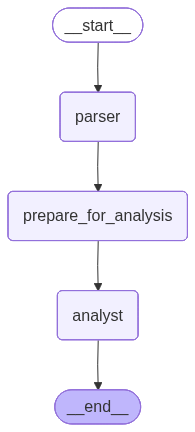

In [8]:
from IPython import display

display.Image(workflow.get_graph().draw_mermaid_png())

### **Step 6: Call the workflow**

In [10]:
from langchain_core.messages import HumanMessage

doc_url = "https://raw.githubusercontent.com/Azure/azure-sdk-for-python/main/sdk/formrecognizer/azure-ai-formrecognizer/tests/sample_forms/forms/Form_1.jpg"

message = HumanMessage(content=f"Analyse the following document {doc_url}")

response = workflow.invoke({"messages" : [message]})

In [11]:
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Analyse the following document https://raw.githubusercontent.com/Azure/azure-sdk-for-python/main/sdk/formrecognizer/azure-ai-formrecognizer/tests/sample_forms/forms/Form_1.jpg
================================== Ai Message ==================================
Tool Calls:
  azure_ai_document_intelligence (call_oFoUgJ6tAWGvBVKCalgkURKP)
 Call ID: call_oFoUgJ6tAWGvBVKCalgkURKP
  Args:
    source_type: url
    source: https://raw.githubusercontent.com/Azure/azure-sdk-for-python/main/sdk/formrecognizer/azure-ai-formrecognizer/tests/sample_forms/forms/Form_1.jpg
================================= Tool Message =================================
Name: azure_ai_document_intelligence

Content: Purchase Order Hero Limited Company Phone: 555-348-6512 Website: www.herolimited.com Email: accounts@herolimited.com Purchase Order Dated As: 12/20/2020 Purchase Order #: 948284 Shipped To Vendor Name: Hillary Swank Company Name: 